# 穷举的困境：无限膨胀的类别

通过本次任务，你将会尝试解决一个实际问题：如何让机器“理解”加法运算，并认知到分类模型的局限性。

## 任务背景

你的无人柠檬水摊生意越来越红火，甚至开始考虑发展连锁经营。但在统计每日销量时，你发现机器人虽然能熟练制作柠檬水，却完全不懂如何算账。于是你决定为它增加一项新技能：自动计算每日各种口味柠檬水的销售总量。

那么，如何让机器人学会加法计算呢？

你灵机一动，想到了一个“巧妙”的办法：既然你的机器人模型已经能够判断用户评价的情感分类，而加法计算的结果其实是有限的（例如，对于三位数加法，结果只在0到1998之间），何不将这个问题视为一个包含1999个类别的超大多分类任务呢？

有了思路，就让我们开始动手实现吧！

## 任务鸟瞰

### 任务分析

本次的任务是使用分类模型对三位数以内的加法运算进行预测。

![任务鸟瞰](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211163947.png)


### 模型结构

加法计算模型和情感分析模型从结构上看没有任何区别，只是分类类别从 2 个增加到 1999 个。模型结构如下：

![模型结构](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211164016.png)

下面我们进入实战部分，依然沿用 NLP 任务的通用开发流程组织本章内容：定义分词器、数据准备、模型定义、模型训练与模型评估。

在正式开始之前，先配置环境，避免因为环境不同而导致程序不能复现。

## 环境配置

### 安装依赖

In [ ]:
!pip install --upgrade dsxllm

### 环境版本

In [21]:
from dsxllm.util import show_version

show_version()

本书愿景：
+------+--------------------------------------------------------+
| Info |                  《动手学大语言模型》                  |
+------+--------------------------------------------------------+
| 作者 |                       吾辈亦有感                       |
| 哔站 |      https://space.bilibili.com/3546632320715420       |
| 定位 | 基于'从零构建'的理念，用实战帮助程序员快速入门大模型。 |
| 愿景 | 若让你的AI学习之路走的更容易一点，我将倍感荣幸！祝好😄 |
+------+--------------------------------------------------------+
环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.10.0    |         2.6.1          |
+-------------+--------------+------------------------+


## 准备数据

### 数据集下载

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('dataset'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/logo.png" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">数据集下载</h4>
                <p class="card-text">
                    如果你想要亲自动手复现运行结果，可以点击此链接下载相关数据集。
                </p>
            </div>
        </div>
    </div>
</a>
```

### 观察数据

本项目是一个新的任务，我们先观察一下训练数据的格式。

In [3]:
# 打开文件并读取前5行
from dsxllm.util import preview_file

preview_file('./dataset/addition_train.txt', 5)

,行数,内容
0,1,12+991=1003
1,2,188+350=538
2,3,60+899=959
3,4,122+72=194
4,5,727+52=779


本次的数据集具有以下特征：
- 每条样本均为一个加法算式，其中等号前的问题是模型输入，等号后的答案是对应的监督标签。
- 词表规模较小，可采用字符级分词器，将每个字符（包括数字0-9、运算符“+”、“=”以及空格等）视为独立的 Token 进行处理。
- 数据集最多只支持三位数以内加法计算，所以模型输入序列的最大长度固定为 7。
- 由于两个三位数相加的结果范围在0至1998之间（两个三位数相加的最大值），模型需要应对近2000个类别的分类任务，分类数量较多。

处理数据时，需要将每一个样本根据等号进行分割，将等号前的问题作为输入，等号后的问题作为标签。具体过程如下所示：

![加法数据处理](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211164102.png)

### 自定义分词器

本次的词表规模较小，使用手动的方式构建分词器的词表，对算式进行编码时需要将较短的算式填充到最大长度 7。

#### 加法分词器的代码实现

In [4]:
from dsxllm.util import print_table
import torch


class SimpleTokenizer:
    def __init__(self, vocab, pad_token, unk_token):
        """
        初始化简单分词器
        """

        self.vocab = vocab

        # 反向词汇表 (id -> token)
        self.ids_to_tokens = {v: k for k, v in self.vocab.items()}

        # 特殊token
        self.pad_token = pad_token
        self.pad_token_id = self.vocab[pad_token]

        self.unk_token = unk_token
        self.unk_token_id = self.vocab[unk_token]

        self.special_tokens = [self.pad_token, self.unk_token]

        # 词汇表大小
        self.vocab_size = len(self.ids_to_tokens)

    def encode(self, text):
        # 将文本拆分为单个字符和特殊标记
        tokens = self._tokenize_special_tokens(text)

        # 将每个token转换为对应的token ID
        input_ids = [self.vocab[token] for token in tokens if token in self.vocab]

        return input_ids

    def _tokenize_special_tokens(self, text):
        # 识别并处理特殊标记
        tokens = []
        i = 0
        while i < len(text):
            # 检查是否匹配特殊标记
            for token in self.special_tokens:
                if text[i:i + len(token)] == token:
                    tokens.append(token)
                    i += len(token)
                    break
            else:
                # 如果不是特殊标记，则逐个字符处理
                tokens.append(text[i])
                i += 1
        return tokens

    def decode(self, input_ids, skip_special_tokens=True):
        # 如果 input_ids 是 torch.Tensor，则转换为列表
        if isinstance(input_ids, torch.Tensor):
            input_ids = input_ids.squeeze().tolist()

        # 将token ID序列转换为对应的字符
        tokens = [self.ids_to_tokens.get(id) for id in input_ids]

        # 去除开始符和结束符
        if skip_special_tokens:
            tokens = [token for token in tokens if token not in self.special_tokens]
        return ''.join(tokens)

    def pad_sequences(self, sequences, max_length):
        """
        对序列进行填充或截断
        """
        padded_sequences = []

        for seq in sequences:
            if len(seq) > max_length:
                # 截断
                padded_seq = seq[:max_length]
            else:
                # 填充
                pad_length = max_length - len(seq)
                padded_seq = seq + [self.pad_token_id] * pad_length

            padded_sequences.append(padded_seq)

        return padded_sequences

    def __call__(self, texts, max_length=10):
        """
        分词器主调用函数
        """
        is_single_text = False

        if isinstance(texts, str):
            is_single_text = True
            texts = [texts]

        # 编码所有文本
        all_token_ids = []
        for text in texts:
            token_ids = self.encode(text)
            all_token_ids.append(token_ids)

        # 填充或截断到统一长度
        padded_token_ids = self.pad_sequences(all_token_ids, max_length)

        if is_single_text:
            padded_token_ids = padded_token_ids[0]

        return padded_token_ids

    def info(self):
        """
        打印分词器的详细信息
        """

        # 通用信息表
        print_table("General Information", field_names=["Information", "Value"], data=[
            ["Vocabulary Size", self.vocab_size],
            ["Padding Token", f"{self.pad_token} (ID: {self.pad_token_id})"]
        ])

        # 字符到ID的映射表
        print_table("Token Mapping", field_names=["Token", "ID"], data=[
            [char, char_id] for char, char_id in self.vocab.items()
        ])

        # 编码解码示例表
        example = "12+991"  # 示例输入
        print_table("Encoding and Decoding Example", field_names=["Input", "Encode", "Decode"], data=[
            [example, self.encode(example), self.decode(self.encode(example))],
        ])

#### 加法分词器的使用实例

使用手动构建的词表初始化分词器。其中，`pad_token` 为空格。

In [5]:
# 手动构建词表
vocab = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "+": 10,
    "=": 11,
    " ": 12,
    "<|unk|>": 13,
}

# 使用词表初始化分词器，并指定填充符和未知符
tokenizer = SimpleTokenizer(vocab, pad_token=" ", unk_token="<|unk|>")
tokenizer.info()  # 打印分词器信息

General Information：
+-----------------+------------+
|   Information   |   Value    |
+-----------------+------------+
| Vocabulary Size |     14     |
|  Padding Token  |   (ID: 12) |
+-----------------+------------+
Token Mapping：
+---------+----+
|  Token  | ID |
+---------+----+
|    0    | 0  |
|    1    | 1  |
|    2    | 2  |
|    3    | 3  |
|    4    | 4  |
|    5    | 5  |
|    6    | 6  |
|    7    | 7  |
|    8    | 8  |
|    9    | 9  |
|    +    | 10 |
|    =    | 11 |
|         | 12 |
| <|unk|> | 13 |
+---------+----+
Encoding and Decoding Example：
+--------+---------------------+--------+
| Input  |        Encode       | Decode |
+--------+---------------------+--------+
| 12+991 | [1, 2, 10, 9, 9, 1] | 12+991 |
+--------+---------------------+--------+


从分词器的编解码示例中可以看到，分词器成功的将输入算式编码成了 Token ID 列表，并且能正确解码回原始算式。

### 加法数据转换器

直接使用分词器将加法算式编码成指定长度的 Token ID 列表，对齐的过程如上图所示。

In [6]:
class TextTransform:
    def __init__(self, tokenizer: SimpleTokenizer, max_length=20):
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __call__(self, text):
        # 使用分词器对输入文本进行编码（会对较短的算式进行填充）
        input_ids = self.tokenizer(text, self.max_length)
        return torch.tensor(input_ids, dtype=torch.long)

### 构造加法数据集

构造加法数据集时，需要将每一个样本根据等号进行分割，将等号前的问题作为输入，等号后的问题作为标签。每一个样本会处理成如下格式：
```json
{
    "question": "12+991",
     "answer": "1003",
     "input_ids": tensor([ 1,  2, 10,  9,  9,  1, 12]),
     "labels": 1003
}
```

- `question` 和 `answer` 为原始的问题和答案，便于后期评估模型的预测结果。
- `input_ids` 是加法算式的 Token IDs，已被处理成 Tensor 格式，方便模型处理。
- `labels` 是答案对应的分类 ID。

#### 加法数据集的代码实现

In [7]:
from torch.utils.data import Dataset


class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, transform: TextTransform):
        self.texts = texts
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        input_ids = self.transform(text)
        answer = str(label)

        return {
            "question": text,  # 原始问题文本
            "answer": answer,  # 原始答案文本
            'input_ids': input_ids,
            'labels': label
        }

    @classmethod
    def from_file(cls, file_path, transform: TextTransform):
        """
        从txt文件加载数据集
        txt格式应包含标签和文本，使用制表符分隔
        """

        texts = []
        labels = []

        # 读取txt文件
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip() == '':  # 跳过空行
                    continue
                try:
                    # 查找等号的位置，将行分割为问题和答案
                    idx = line.find('=')
                    # 将样本添加到列表中: (question, answer)，answer中去掉"="以及最后的"\n"
                    question = line[:idx]
                    answer = line[idx + 1:].strip()
                    texts.append(question)
                    labels.append(int(answer))
                except Exception as e:
                    # 如果处理某行时出错，打印错误信息并跳过
                    print(f"Error processing line: {line}")
                    print(f"Error message: {e}")
                    continue

        # 创建数据集实例
        return cls(texts, labels, transform)

#### 创建加法数据集实例

In [8]:
from pprint import pprint

# 最大长度（3位数 + '加号' + 3位数）
max_length = 7

# 1️⃣ 初始化分词器
tokenizer = SimpleTokenizer(vocab, pad_token=" ", unk_token="<|unk|>")

# 2️⃣ 初始化数据转换
transform = TextTransform(tokenizer, max_length=max_length)

# 3️⃣ 加载数据集
file_path = "./dataset/addition_train.txt"
dataset = TextClassificationDataset.from_file(file_path, transform=transform)

# 打印一条数据，观察数据转换结果
pprint(dataset[0], sort_dicts=False)

{'question': '12+991',
 'answer': '1003',
 'input_ids': tensor([ 1,  2, 10,  9,  9,  1, 12]),
 'labels': 1003}


从打印的样本中可以看到，训练语料中的加法算式被处理成了正确的训练格式。原始的 6 位数加法算式被填充成了 7 位。

### 创建加法数据模组

加法数据模组继承自 LightningDataModule，用于加载训练、验证和测试数据集。

#### 加法数据模组的代码实现

In [9]:
import lightning as L
from torch.utils.data import DataLoader


class TextDataModule(L.LightningDataModule):
    def __init__(self, batch_size, transform: TextTransform, train_data_file, val_data_file="", test_data_file=""):
        super().__init__()

        # 数据集文件路径
        self.train_data_file = train_data_file
        self.val_data_file = val_data_file
        self.test_data_file = test_data_file

        # 数据集实例
        self.test_dataset = None  # 测试数据集实例
        self.val_dataset = None  # 验证数据集实例
        self.train_dataset = None  # 训练数据集实例

        self.batch_size = batch_size
        self.transform = transform

    def prepare_data(self):
        # 下载或准备数据集的操作（如果需要）
        pass

    def setup(self, stage=None):
        # 加载训练数据集
        self.train_dataset = TextClassificationDataset.from_file(self.train_data_file, transform=self.transform)

        # 加载验证数据集
        if self.val_data_file == "":
            self.val_dataset = self.train_dataset
        else:
            self.val_dataset = TextClassificationDataset.from_file(self.val_data_file, transform=self.transform)

        # 加载测试数据集
        if self.test_data_file == "":
            self.test_dataset = self.train_dataset
        else:
            self.test_dataset = TextClassificationDataset.from_file(self.test_data_file, transform=self.transform)

    def train_dataloader(self):
        # 返回训练数据的DataLoader，设置批次大小并打乱数据顺序
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        # 返回验证数据的DataLoader，设置批次大小，不打乱数据顺序
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        # 返回测试数据的DataLoader，设置批次大小，不打乱数据顺序
        return DataLoader(self.test_dataset, batch_size=self.batch_size)


#### 创建加法数据模组实例

In [10]:
from pprint import pprint

# 最大长度（3位数 + '加号' + 3位数）
max_length = 7

# 1️⃣ 初始化分词器
tokenizer = SimpleTokenizer(vocab, pad_token=" ", unk_token="<|unk|>")

# 2️⃣ 初始化数据转换
transform = TextTransform(tokenizer, max_length=max_length)

# 3️⃣ 加载数据模组
text_datamodule = TextDataModule(batch_size=2, transform=transform, train_data_file="./dataset/addition_train.txt",
                                 val_data_file="./dataset/addition_val.txt")

# 4️⃣ 调用 setup 方法初始化数据集
text_datamodule.setup()

print("数据集信息：")
print("训练集样本数量：", len(text_datamodule.train_dataset))
print("评估集样本数量", len(text_datamodule.val_dataset))

# 打印一个批次的数据
print("\n打印一个批次的数据：")
for batch in text_datamodule.train_dataloader():
    pprint(batch, sort_dicts=False)
    break

数据集信息：
训练集样本数量： 45000
评估集样本数量 5000

打印一个批次的数据：
{'question': ['89+65', '71+685'],
 'answer': ['154', '756'],
 'input_ids': tensor([[ 8,  9, 10,  6,  5, 12, 12],
        [ 7,  1, 10,  6,  8,  5, 12]]),
 'labels': tensor([154, 756])}


## 构建加法计算模型

加法计算模型继承自 LightningModule，模型结构如下：

![模型结构](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211164016.png)

本次任务只使用一个单向的GRU层，提取加法算式的语义信息。前向计算的过程如下所示：

![加法计算的过程](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211174744.png)

### 加法计算模型的代码实现

本次的加法计算模型和之前的情感分析模型都是文本分类模型，因此模型的结构相似，这里不再赘述，只给出模型代码。

In [11]:
import torch
import lightning as L
from torch import nn
import torch.nn.functional as F


class TextClassifier(L.LightningModule):
    def __init__(self, vocab_size, hidden_size, num_classes, learning_rate=0.01, dropout_p=0.1):
        super(TextClassifier, self).__init__()

        # 学习率, 用于设置优化器
        self.learning_rate = learning_rate
        # 标签id到标签的映射，用于预测解码
        self.ids_to_labels = None

        # 定义网络层
        # 嵌入层：将词索引映射到高维向量
        self.token_emb_layer = nn.Embedding(vocab_size, hidden_size)
        # GRU层：用于处理序列数据
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        # Dropout层：防止过拟合
        self.dropout = nn.Dropout(dropout_p)
        # 输出层：将GRU的输出映射到标签空间
        self.output_layer = nn.Linear(hidden_size, num_classes)

        # 存储每个训练步骤和训练循环的损失
        self.train_step_losses = []
        self.train_epoch_losses = []

        # 用于存储验证步骤的结果
        self.validation_step_outputs = []
        self.eval_accuracies = []

        # 示例输入
        self.example_input_array = torch.randint(0, vocab_size, (32, 7), dtype=torch.long)

    def forward(self, input_ids):
        """前向传播"""
        token_embeds = self.dropout(self.token_emb_layer(input_ids))  # 嵌入并应用dropout
        gru_output, gru_hidden = self.gru(token_embeds)  # 通过GRU处理, 得到输出和隐藏状态

        # 取出最后一层的隐藏状态（对于单层GRU，索引为-1或0都可以）
        last_hidden = gru_hidden[-1]  # 形状: (batch_size, hidden_size)

        # 将最后一个时间步的特征输入到输出层
        out = self.output_layer(last_hidden)  # 形状: (batch_size, num_classes)

        return out

    def training_step(self, batch, batch_idx):
        """训练步骤"""
        input_ids = batch["input_ids"]
        labels = batch["labels"]

        # 前向传播
        outputs = self(input_ids)
        loss = F.cross_entropy(outputs, labels)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()

        # 记录日志
        self.log('train_loss', loss)
        self.log('train_acc', acc)

        # 存储损失以便后续使用
        self.train_step_losses.append(loss.detach())

        return loss

    def on_train_epoch_end(self):
        """在每个训练epoch结束时计算整体损失"""

        if self.train_step_losses:  # 确保列表不为空
            # 计算并记录平均训练损失
            avg_train_loss = torch.stack(self.train_step_losses).mean()
            self.train_epoch_losses.append({
                "epoch": self.current_epoch,
                "loss": avg_train_loss.item()  # 转换为 Python 数值
            })

            # 清空列表为下一个 epoch 做准备
            self.train_step_losses.clear()

    def validation_step(self, batch, batch_idx):
        """验证步骤"""
        input_ids = batch["input_ids"]
        labels = batch["labels"]

        # 前向传播
        outputs = self(input_ids)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)

        # 保存结果供epoch结束时使用
        self.validation_step_outputs.append({'preds': preds, 'labels': labels})

    def on_validation_epoch_end(self):
        """在每个验证epoch结束时计算整体准确率"""
        # 汇总所有预测结果和标签
        all_preds = torch.cat([x['preds'] for x in self.validation_step_outputs])
        all_labels = torch.cat([x['labels'] for x in self.validation_step_outputs])

        # 计算整体准确率
        val_overall_acc = (all_preds == all_labels).float().mean()

        # 记录整体准确率
        self.log('total_samples', len(all_labels))
        self.log('total_correct', (all_preds == all_labels).float().sum())
        self.log('val_overall_acc', val_overall_acc)

        # 将评估结果保存到 eval_accuracies 列表中
        self.eval_accuracies.append({
            "epoch": self.current_epoch,  # epoch编号
            "总样本数": len(all_labels),  # 验证集总样本数
            "正确样本数": int((all_preds == all_labels).float().sum().item()),  # 预测正确的样本数
            "准确率": round(val_overall_acc.item(), 4)  # 准确率
        })

        # 清空缓存
        self.validation_step_outputs.clear()

    def clear_cache(self):
        """清除缓存"""
        self.train_step_losses.clear()
        self.train_epoch_losses.clear()
        self.validation_step_outputs.clear()
        self.eval_accuracies.clear()

    def configure_optimizers(self):
        """配置优化器"""
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def setup_label_map(self, ids_to_labels=None):
        """根据数据集设置标签映射"""
        self.ids_to_labels = ids_to_labels

    def predict(self, input_ids):
        """
        对新数据进行预测
        
        Args:
            input_ids: 输入特征，可以是单个样本或批量样本
        Returns:
            predictions: 预测的标签索引
            decoded_predictions: 解码后的标签名称
            probabilities: 预测概率
        """
        # 确保模型处于评估模式
        self.eval()

        # 【新增】判断输入类型并处理
        if isinstance(input_ids, list):
            input_ids = torch.stack(input_ids)  # 转换为张量

        # 确保输入是tensor格式
        if not isinstance(input_ids, torch.Tensor):
            input_ids = torch.tensor(input_ids, dtype=torch.float32)

        # 预测
        with torch.no_grad():
            outputs = self(input_ids)
            predictions = torch.argmax(outputs, dim=1).tolist()
            probabilities = torch.softmax(outputs, dim=1).tolist()

        # 解码预测结果
        decoded_predictions = [self.ids_to_labels[pred] for pred in predictions]

        return predictions, decoded_predictions, probabilities

    def decode_labels(self, label_ids):
        """
        将标签ID解码为标签名称
        
        Args:
            label_ids: 标签ID列表
        Returns:
            decoded_labels: 解码后的标签名称列表
        """
        if isinstance(label_ids, torch.Tensor):
            label_ids = label_ids.tolist()
        return [self.ids_to_labels[label_id] for label_id in label_ids]

### 加法计算模型的详细信息

In [12]:
from lightning.pytorch.utilities.model_summary import ModelSummary

# 创建从0到1998的ids_to_labels映射（用于三位数以内的加法）
ids_to_labels = {i: str(i) for i in range(1999)}

# 创建加法计算模型实例
model = TextClassifier(vocab_size=tokenizer.vocab_size, hidden_size=128, num_classes=len(ids_to_labels),
                       learning_rate=0.001)

summary = ModelSummary(model, max_depth=-1)
print(summary)

  | Name            | Type      | Params | Mode  | FLOPs  | In sizes     | Out sizes                   
-------------------------------------------------------------------------------------------------------------
0 | token_emb_layer | Embedding | 1.8 K  | train | 0      | [32, 7]      | [32, 7, 128]                
1 | gru             | GRU       | 99.1 K | train | 44.0 M | [32, 7, 128] | [[32, 7, 128], [1, 32, 128]]
2 | dropout         | Dropout   | 0      | train | 0      | [32, 7, 128] | [32, 7, 128]                
3 | output_layer    | Linear    | 257 K  | train | 16.4 M | [32, 128]    | [32, 1999]                  
-------------------------------------------------------------------------------------------------------------
358 K     Trainable params
0         Non-trainable params
358 K     Total params
1.435     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode
60.4 M    Total Flops


从模型摘要中可以看到：嵌入层 `token_emb_layer` 的输入形状为 `[32,7 ]` 对应着 `(batch_size, max_length)`；输出层 `output_layer` 的输出形状为 `[32, 1999]` 对应着 `(batch_size, num_classes)`。也就是说，这是一个将序列长度为 7 的文本分成 1999 个类别的文本分类模型。

## 模型的训练与评估

### 初始化模型和训练器

In [13]:
# 超参数配置
max_length = 7  # 最大长度
batch_size = 32  # 批量大小

# 1️⃣ 初始化分词器
tokenizer = SimpleTokenizer(vocab, pad_token=" ", unk_token="<|unk|>")

# 2️⃣ 初始化数据转换
transform = TextTransform(tokenizer, max_length=max_length)

# 3️⃣ 加载数据模组
file_path = "./dataset/addition_train.txt"
datamodule = TextDataModule(batch_size=batch_size, transform=transform, train_data_file=file_path)

# 4️⃣ 初始化模型
model = TextClassifier(vocab_size=tokenizer.vocab_size, hidden_size=128, num_classes=len(ids_to_labels),
                       learning_rate=0.001)

# 5️⃣ 初始化训练器
# max_epochs=12: 最大训练轮数为12
# log_every_n_steps=3: 每3个步骤记录一次日志
# check_val_every_n_epoch=1: 每1个epoch进行一次验证
# num_sanity_val_steps=0: 验证集的初始检查次数，设置为0表示不进行初始检查
# enable_progress_bar=False: 不显示进度条
trainer = L.Trainer(max_epochs=12, log_every_n_steps=3, check_val_every_n_epoch=1, num_sanity_val_steps=0,
                    enable_progress_bar=False)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### 训练前评估

训练前评估为模型性能建立初始性能基准。

In [14]:
# 直接调用验证函数进行评估
trainer.validate(model=model, datamodule=datamodule)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │           55.0            │
│       total_samples       │          45000.0          │
│      val_overall_acc      │   0.0012222222285345197   │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 45000.0,
  'total_correct': 55.0,
  'val_overall_acc': 0.0012222222285345197}]

加法计算器训练前评估的初始准确率为 `0.12%`。

### 训练模型

调用 `trainer.fit()` 训练 12 个轮次。

In [15]:
model.clear_cache()
trainer.fit(model=model, datamodule=datamodule)

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   ┃ Name            ┃ Type      ┃ Params ┃ Mode  ┃  FLOPs ┃     In sizes ┃                    Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 0 │ token_emb_layer │ Embedding │  1.8 K │ train │      0 │      [32, 7] │                 [32, 7, 128] │
│ 1 │ gru             │ GRU       │ 99.1 K │ train │ 44.0 M │ [32, 7, 128] │ [[32, 7, 128], [1, 32, 128]] │
│ 2 │ dropout         │ Dropout   │      0 │ train │      0 │ [32, 7, 128] │                 [32, 7, 128] │
│ 3 │ output_layer    │ Linear    │  257 K │ train │ 16.4 M │    [32, 128] │                   [32, 1999] │
└───┴─────────────────┴───────────┴────────┴───────┴────────┴──────────────┴──────────────────────────────┘

Trainable params: 358 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 358 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 60.4 M

`Trainer.fit` stopped: `max_epochs=12` reached.


#### 训练过程可视化

绘制训练过程中损失值的变化曲线。

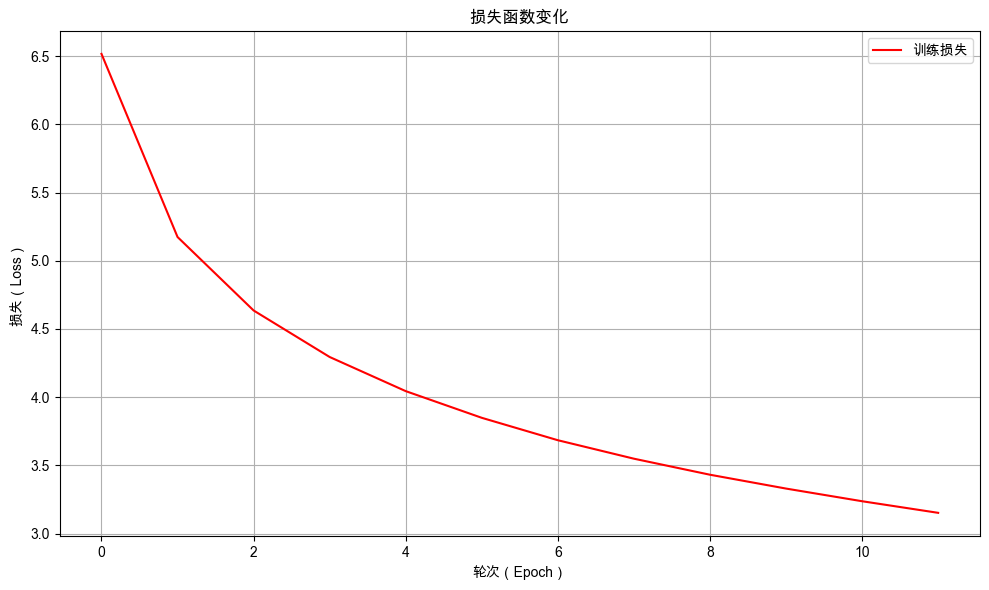

In [16]:
from dsxllm.util import plot_loss_curves

plot_loss_curves(model.train_epoch_losses)


#### 查看模型评估记录

查看训练过程中的评估结果，观察模型在验证集上的表现。

In [17]:
from dsxllm.util import to_dataframe

to_dataframe(model.eval_accuracies)


,epoch,总样本数,正确样本数,准确率
0,0,45000,681,0.0151
1,1,45000,1537,0.0342
2,2,45000,2522,0.0560
3,3,45000,3275,0.0728
4,4,45000,4032,0.0896
5,5,45000,4993,0.1110
6,6,45000,5574,0.1239
7,7,45000,6319,0.1404
8,8,45000,6966,0.1548
9,9,45000,7522,0.1672


在训练过程中，模型在验证集上的准确率不断提高，说明模型的训练是有效的。

### 训练后评估

In [18]:
# 直接调用验证函数进行评估
trainer.validate(model=model, datamodule=datamodule)

/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          8891.0           │
│       total_samples       │          45000.0          │
│      val_overall_acc      │    0.19757777452468872    │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 45000.0,
  'total_correct': 8891.0,
  'val_overall_acc': 0.19757777452468872}]

模型经过训练后，预测准确率从 `0.12%` 提升至 `19.75%`，准确率虽然提升明显，但最终的准确率仍然较低。

## 使用模型进行预测


使用一些测试算式进行推理预测，直观观察模型的预测效果。

In [19]:
from dsxllm.util import print_classification_predictions

# 1️⃣ 创建一些测试问题和答案
questions = ["829+33", "58+136", "22+593", "243+269", "1+1"]
answers = [862, 194, 615, 512, 2]

# 2️⃣ 使用与训练时统一的 transform 方法对文本进行处理
input_ids = []
for text in questions:
    # 使用训练时相同的 transform 方法
    transformed = transform(text)
    input_ids.append(transformed)

# 3️⃣ 使用模型进行预测
model.setup_label_map(ids_to_labels=ids_to_labels)
predictions, decoded_predictions, probabilities = model.predict(input_ids)

# 4️⃣ 展示预测结果
print_classification_predictions(questions, answers, predictions, probabilities, model.ids_to_labels)

🎯 分类预测结果 (准确率: 1/5 = 20.00%)：
+---------+----------+----------+----------+------+
|   输入  | 真实标签 | 预测标签 | 最高概率 | 标记 |
+---------+----------+----------+----------+------+
|  829+33 |   862    |   858    |  0.1697  |  ☒   |
|  58+136 |   194    |   186    |  0.3381  |  ☒   |
|  22+593 |   615    |   627    |  0.0898  |  ☒   |
| 243+269 |   512    |   512    |  0.0690  |  ☑   |
|   1+1   |    2     |    10    |  0.1706  |  ☒   |
+---------+----------+----------+----------+------+


本次的加法计算模型预测正确率只有 `20%`，表现很差，需要进一步优化模型。

## 泛化能力评估

In [20]:
from dsxllm.util import print_red

datamodule2 = TextDataModule(batch_size=batch_size, transform=transform,
                             train_data_file="./dataset/addition_train.txt",
                             val_data_file="./dataset/addition_val.txt")

print_red("在训练集上评估：")
trainer.validate(model=model, datamodule=datamodule)

print_red("在评估集上评估：")
trainer.validate(model=model, datamodule=datamodule2)

在训练集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          8891.0           │
│       total_samples       │          45000.0          │
│      val_overall_acc      │    0.19757777452468872    │
└───────────────────────────┴───────────────────────────┘

在评估集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │           222.0           │
│       total_samples       │          5000.0           │
│      val_overall_acc      │    0.04439999908208847    │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 5000.0,
  'total_correct': 222.0,
  'val_overall_acc': 0.04439999908208847}]

模型在评估集上的准确率只有 `4.43%`，过拟合现象严重，但模型泛化能力很弱。

## 本章小结

本次的项目我们试图使用文本分类模型解决加法计算问题。虽然可以通过将每个可能的结果视为一个独立的类别来进行预测，但这种方法会导致分类类型的总数急剧增加，导致模型参数剧增、训练数据稀疏且无法泛化到未见过的值，此外，当面对更大范围的数值或更复杂的运算时，这种穷举分类的方法变得不可行，因为类别数量会呈指数级增长，严重影响模型的性能和实用性。

而文本生成方法通过将加法转化为序列生成任务（如逐位预测数字），仅需有限字符集即可建模任意长度加法，避免了类别爆炸问题，显著提升模型的可扩展性与泛化能力。在下一章中，我们将介绍如何使用文本生成方法来解决加法计算问题。

## 答疑讨论

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('qa'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/logo.png" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">答疑讨论</h4>
                <p class="card-text">
                    如果你有任何学习上的疑问，可以评论留言，和我一起讨论。我会抽空回复你的问题，也欢迎你回答其他人的问题。
                </p>
            </div>
        </div>
    </div>
</a>
```